In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('gene_expression_ml.csv')
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


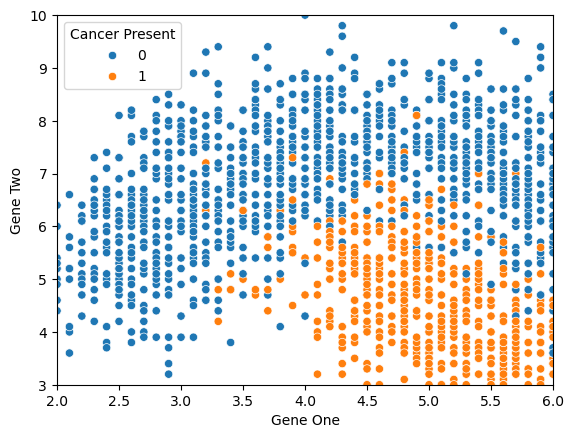

In [51]:
sns.scatterplot(data=df,x='Gene One',y='Gene Two',hue='Cancer Present')
plt.ylim(3,10)
plt.xlim(2,6)
plt.show()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gene One        3000 non-null   float64
 1   Gene Two        3000 non-null   float64
 2   Cancer Present  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
X= df.drop('Cancer Present',axis=1)
y= df['Cancer Present']

In [7]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.3, random_state=101)

In [8]:
sc= StandardScaler()

In [9]:
sc_X_train= sc.fit_transform(X_train)
sc_X_test= sc.transform(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
knn_model= KNeighborsClassifier(n_neighbors=1)

In [12]:
knn_model.fit(sc_X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

### Interpret KNN and choosing the K value

In [13]:
y_pred= knn_model.predict(sc_X_test)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [15]:
accuracy_score(y_test,y_pred)

0.9166666666666666

In [16]:
confusion_matrix(y_test,y_pred)

array([[382,  41],
       [ 34, 443]])

In [17]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       423
           1       0.92      0.93      0.92       477

    accuracy                           0.92       900
   macro avg       0.92      0.92      0.92       900
weighted avg       0.92      0.92      0.92       900



### Elbow method for choosing reasonable K

In [18]:
test_error_rates=[]

for k in range(1,30):
    knn_model= KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(sc_X_train,y_train)

    y_pred_test=knn_model.predict(sc_X_test)
    test_error= 1-accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)

In [19]:
test_error_rates

[0.08333333333333337,
 0.0922222222222222,
 0.07111111111111112,
 0.06555555555555559,
 0.06444444444444442,
 0.05888888888888888,
 0.06555555555555559,
 0.06333333333333335,
 0.06555555555555559,
 0.06333333333333335,
 0.06888888888888889,
 0.06333333333333335,
 0.06444444444444442,
 0.06222222222222218,
 0.06777777777777783,
 0.061111111111111116,
 0.06000000000000005,
 0.061111111111111116,
 0.06333333333333335,
 0.06222222222222218,
 0.06222222222222218,
 0.06444444444444442,
 0.061111111111111116,
 0.06000000000000005,
 0.06222222222222218,
 0.06555555555555559,
 0.06222222222222218,
 0.061111111111111116,
 0.06222222222222218]

Text(0.5, 0, 'K Value')

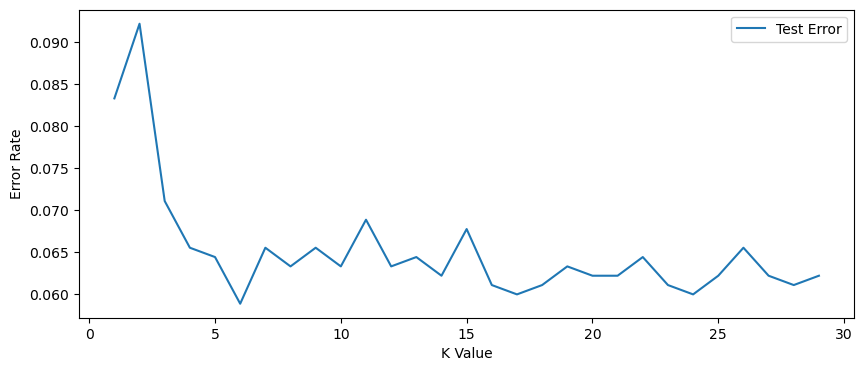

In [20]:
plt.figure(figsize=(10,4))
plt.plot(range(1,30), test_error_rates, label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel('K Value')

### Full Cross Validation grid search for K value

#### Creating a pipeline to find K value

In [26]:
scaler= StandardScaler()

In [22]:
knn= KNeighborsClassifier()

In [23]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [24]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [27]:
operations= [('scaler',scaler),('knn',knn)]

In [28]:
from sklearn.pipeline import Pipeline

In [29]:
pipe= Pipeline(operations)

In [30]:
from sklearn.model_selection import GridSearchCV

In [36]:
k_values= list(range(1,20))

In [37]:
k_values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

* chosen string name of model+ two underscores+ parameter key name

In [38]:
param_grid= {'knn__n_neighbors':k_values}

In [39]:
full_cv_classifier= GridSearchCV(pipe,param_grid,cv=10, scoring='accuracy')

In [40]:
full_cv_classifier.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy')

In [41]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=18))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=18),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 18,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [42]:
len(k_values)

19

In [43]:
full_cv_classifier.cv_results_['mean_test_score']

array([0.89571429, 0.90714286, 0.92      , 0.91857143, 0.9247619 ,
       0.92714286, 0.9252381 , 0.92761905, 0.92809524, 0.92952381,
       0.92809524, 0.92809524, 0.92809524, 0.92857143, 0.92952381,
       0.92952381, 0.93095238, 0.93333333, 0.93142857])

In [44]:
len(full_cv_classifier.cv_results_['mean_test_score'])

19

### Final Model

In [45]:
knn18= KNeighborsClassifier(n_neighbors=18)
operations= [('scaler',scaler),('knn18',knn18)]

In [46]:
pipe= Pipeline(operations)

In [47]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn18', KNeighborsClassifier(n_neighbors=18))])

In [48]:
pipe_pred= pipe.predict(X_test)

In [50]:
print(classification_report(y_test,pipe_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       423
           1       0.94      0.94      0.94       477

    accuracy                           0.94       900
   macro avg       0.94      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900



In [57]:
pipe.predict_proba([[4.5,6.8],[5.6,3.4]])

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.77777778, 0.22222222],
       [0.        , 1.        ]])

In [60]:
#this means that it is 77 percent sure that the patient is cancer free
# and in 2nd case it is 100 percent sure that the patient have cancer

In [58]:
pipe.predict([[4.5,6.8],[5.6,3.4]])

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0, 1])